# 07 — Random Forest

Este notebook compara la base depurada de 24 variables con la poda de 17 variables obtenida mediante Decision Tree. La comparación, la selección del conjunto y la búsqueda de hiperparámetros utilizan exclusivamente 2015–2016. El mejor bosque se evalúa una única vez sobre el holdout temporal de 2017.

Random Forest puede aprender cortes e interacciones directamente, por lo que conserva `LeadTime` continuo y no incorpora automáticamente las representaciones elegidas para Logistic Regression.

## Imports y resolución de la raíz

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)

In [2]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "src").is_dir():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz local del proyecto.")
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)
print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.config import RANDOM_STATE, RAW_DATA_DIR
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.evaluation import (
    cross_validate_model,
    evaluate_binary_classifier,
    get_grid_results,
    get_stratified_group_cross_validation,
    run_grid_search,
)
from src.features import (
    build_base_feature_set,
    build_tree_model_feature_sets,
    get_feature_types,
    make_exact_feature_groups,
)
from src.plots import plot_confusion_matrix
from src.preprocessing import build_tabular_preprocessor

## Carga, conjuntos y división temporal

In [4]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = normalize_text_values(combine_hotel_datasets(h1_df, h2_df))
X_reference, y = build_base_feature_set(bookings_df)
tree_model_feature_sets = build_tree_model_feature_sets(X_reference)

X_reference_train, X_reference_holdout, y_train, y_holdout = make_temporal_holdout_split(
    X_reference,
    y,
    period_values=X_reference["ArrivalDateYear"],
    validation_period=2017,
)
feature_sets_train = {
    name: frame.loc[X_reference_train.index].copy()
    for name, frame in tree_model_feature_sets.items()
}
feature_sets_holdout = {
    name: frame.loc[X_reference_holdout.index].copy()
    for name, frame in tree_model_feature_sets.items()
}

feature_set_summary = pd.DataFrame([
    {
        "feature_set": name,
        "feature_count": frame.shape[1],
        "development_rows": len(frame),
        "holdout_rows": len(feature_sets_holdout[name]),
    }
    for name, frame in feature_sets_train.items()
])
display(feature_set_summary)

,feature_set,feature_count,development_rows,holdout_rows
0,Cleaned base | 24 features,24,78703,40687
1,Tree-pruned | 17 features,17,78703,40687


## Comparación controlada de los conjuntos

Se utiliza un bosque fijo para aislar el efecto de las variables. Ambos candidatos comparten los grupos calculados sobre el conjunto podado, garantizando que las combinaciones idénticas del conjunto más reducido permanezcan en el mismo fold. El escalado no es necesario para árboles.

In [5]:
PRUNED_SET_NAME = "Tree-pruned | 17 features"
comparison_groups = make_exact_feature_groups(feature_sets_train[PRUNED_SET_NAME])


def build_random_forest_pipeline(X, **model_parameters):
    numeric_features, categorical_features = get_feature_types(
        X, require_all_categorical=False
    )
    preprocessor = build_tabular_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=False,
    )
    default_parameters = {
        "n_estimators": 250,
        "max_depth": 14,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
        "n_jobs": 1,
        "random_state": RANDOM_STATE,
    }
    default_parameters.update(model_parameters)
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(**default_parameters)),
    ])

In [6]:
feature_set_records = []
feature_set_fold_records = []
for feature_set_name, X_candidate in feature_sets_train.items():
    comparison_cv = get_stratified_group_cross_validation(n_splits=5)
    scores = cross_validate_model(
        estimator=build_random_forest_pipeline(X_candidate),
        X=X_candidate,
        y=y_train,
        scoring="roc_auc",
        cv=comparison_cv,
        groups=comparison_groups,
        n_jobs=-1,
    )
    feature_set_records.append({
        "feature_set": feature_set_name,
        "feature_count": X_candidate.shape[1],
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std": scores.std(),
    })
    feature_set_fold_records.extend([
        {"feature_set": feature_set_name, "fold": fold, "roc_auc": score}
        for fold, score in enumerate(scores, start=1)
    ])

feature_set_results = pd.DataFrame(feature_set_records).sort_values(
    "cv_roc_auc_mean", ascending=False
).reset_index(drop=True)
comparison_reference_score = feature_set_results.loc[
    feature_set_results["feature_set"].eq("Cleaned base | 24 features"),
    "cv_roc_auc_mean",
].iloc[0]
feature_set_results["delta_vs_cleaned_base"] = (
    feature_set_results["cv_roc_auc_mean"] - comparison_reference_score
)
feature_set_fold_results = pd.DataFrame(feature_set_fold_records)
selected_feature_set_name = feature_set_results.iloc[0]["feature_set"]

display(feature_set_results.round(6))
display(feature_set_fold_results.pivot(
    index="fold", columns="feature_set", values="roc_auc"
).round(6))
print(f"Conjunto seleccionado para la grilla: {selected_feature_set_name}")

,feature_set,feature_count,cv_roc_auc_mean,cv_roc_auc_std,delta_vs_cleaned_base
0,Cleaned base | 24 features,24,0.926422,0.003541,0.00000
1,Tree-pruned | 17 features,17,0.925012,0.003409,-0.00141


feature_set,Cleaned base | 24 features,Tree-pruned | 17 features
fold,,
1,0.920676,0.920422
2,0.928496,0.926950
3,0.929225,0.929395
4,0.929782,0.926654
5,0.923928,0.921640


Conjunto seleccionado para la grilla: Cleaned base | 24 features


## Búsqueda moderada de hiperparámetros

Se conservan dos grillas para documentar el proceso. La búsqueda completa compara 12 configuraciones con 300 árboles y permitió identificar `max_features=0.5`, `min_samples_leaf=5` y profundidad libre como mejor región. La grilla de confirmación compara únicamente profundidad 18 y libre, utiliza 100 árboles y requiere 10 ajustes. `RUN_FULL_RANDOM_FOREST_GRID` permite reproducir la búsqueda completa; por defecto se ejecuta la confirmación económica. El paralelismo se controla desde GridSearchCV para evitar procesos anidados.

In [7]:
X_selected_train = feature_sets_train[selected_feature_set_name]
X_selected_holdout = feature_sets_holdout[selected_feature_set_name]
selected_groups = comparison_groups

RUN_FULL_RANDOM_FOREST_GRID = False

random_forest_full_param_grid = {
    "model__max_depth": [12, 18, None],
    "model__min_samples_leaf": [5, 20],
    "model__max_features": ["sqrt", 0.5],
}
random_forest_light_param_grid = {
    "model__max_depth": [18, None],
    "model__min_samples_leaf": [5],
    "model__max_features": [0.5],
}

random_forest_param_grid = (
    random_forest_full_param_grid
    if RUN_FULL_RANDOM_FOREST_GRID
    else random_forest_light_param_grid
)
random_forest_n_estimators = 300 if RUN_FULL_RANDOM_FOREST_GRID else 100
random_forest_pipeline = build_random_forest_pipeline(
    X_selected_train, n_estimators=random_forest_n_estimators
)
grid_size = np.prod([len(values) for values in random_forest_param_grid.values()])
grid_name = "completa" if RUN_FULL_RANDOM_FOREST_GRID else "liviana"
print(
    f"Grilla {grid_name}: {grid_size} configuraciones, "
    f"{grid_size * 5} ajustes y {random_forest_n_estimators} árboles por bosque."
)

Grilla liviana: 2 configuraciones, 10 ajustes y 100 árboles por bosque.


In [8]:
random_forest_cv = get_stratified_group_cross_validation(n_splits=5)
random_forest_search = run_grid_search(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    X=X_selected_train,
    y=y_train,
    scoring="roc_auc",
    cv=random_forest_cv,
    groups=selected_groups,
    n_jobs=-1,
)
rf_grid_results = get_grid_results(random_forest_search)
rf_grid_results["train_validation_gap"] = (
    rf_grid_results["mean_train_score"] - rf_grid_results["mean_test_score"]
)
rf_result_columns = [
    "params", "mean_train_score", "mean_test_score",
    "std_test_score", "train_validation_gap", "rank_test_score",
]
display(rf_grid_results[rf_result_columns].round(6))
print(f"Mejores parámetros: {random_forest_search.best_params_}")
print(f"Mejor ROC AUC CV: {random_forest_search.best_score_:.6f}")

,params,mean_train_score,mean_test_score,std_test_score,train_validation_gap,rank_test_score
0,"{'model__max_depth': None, 'model__max_feature...",0.987653,0.941260,0.003604,0.046393,1
1,"{'model__max_depth': 18, 'model__max_features'...",0.977951,0.940585,0.003463,0.037366,2


Mejores parámetros: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 5}
Mejor ROC AUC CV: 0.941260


## Evaluación única sobre el holdout temporal

Una vez seleccionados conjunto e hiperparámetros, el mejor bosque se evalúa sobre 2017. Este resultado no se utiliza para reajustar el modelo. El threshold permanece en 0,5 para comparar métricas basadas en clases.

In [9]:
best_random_forest = random_forest_search.best_estimator_
random_forest_metrics = evaluate_binary_classifier(
    best_random_forest, X_selected_holdout, y_holdout, threshold=0.5
)
technical_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression engineered",
        "cv_roc_auc": 0.908557, "holdout_roc_auc": 0.855017,
        "accuracy": 0.739032, "precision": 0.620290,
        "recall": 0.839568, "f1": 0.713461,
    },
    {
        "model": "Decision Tree pruned",
        "cv_roc_auc": 0.927092, "holdout_roc_auc": 0.838694,
        "accuracy": 0.765822, "precision": 0.723456,
        "recall": 0.639187, "f1": 0.678716,
    },
    {
        "model": "Random Forest",
        "cv_roc_auc": random_forest_search.best_score_,
        "holdout_roc_auc": random_forest_metrics["roc_auc"],
        "accuracy": random_forest_metrics["accuracy"],
        "precision": random_forest_metrics["precision"],
        "recall": random_forest_metrics["recall"],
        "f1": random_forest_metrics["f1"],
    },
]).set_index("model")
display(technical_comparison.round(6))
print(f"Gap CV–holdout: {random_forest_search.best_score_ - random_forest_metrics['roc_auc']:.6f}")

,cv_roc_auc,holdout_roc_auc,accuracy,precision,recall,f1
model,,,,,,
Logistic Regression engineered,0.908557,0.855017,0.739032,0.620290,0.839568,0.713461
Decision Tree pruned,0.927092,0.838694,0.765822,0.723456,0.639187,0.678716
Random Forest,0.941260,0.842641,0.769312,0.748885,0.607621,0.670898


Gap CV–holdout: 0.098618


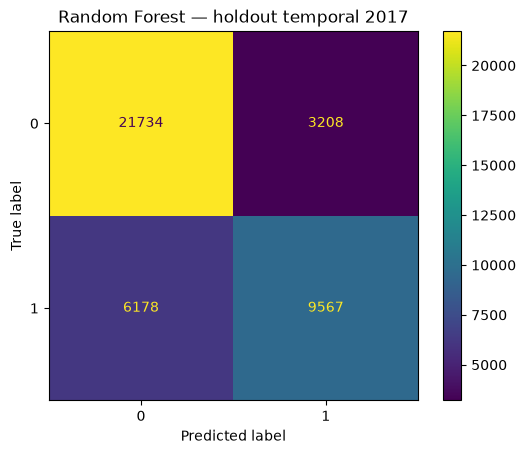

In [10]:
plot_confusion_matrix(
    best_random_forest,
    X_selected_holdout,
    y_holdout,
    threshold=0.5,
    title="Random Forest — holdout temporal 2017",
)

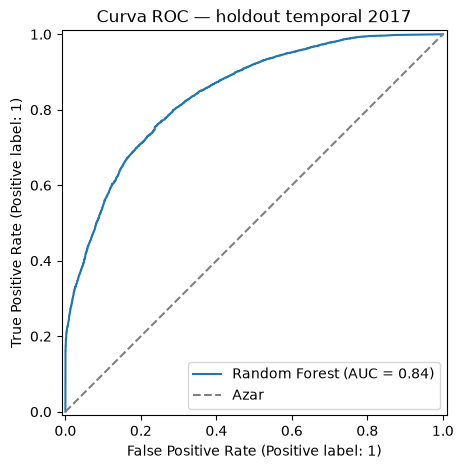

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    best_random_forest, X_selected_holdout, y_holdout,
    name="Random Forest", ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC — holdout temporal 2017")
ax.legend(loc="lower right")
plt.show()

## Importancia agregada del bosque

Las importancias por impureza de las columnas one-hot se agrupan por variable original. Se utilizan como descripción del bosque final, no para realizar nuevas selecciones después de consultar el holdout.

,source_feature,impurity_importance
14,LeadTime,0.188218
6,Country,0.186697
15,MarketSegment,0.099998
23,TotalOfSpecialRequests,0.091949
18,PreviousCancellations,0.071894
1,ArrivalDateDayOfMonth,0.048372
2,ArrivalDateMonth,0.047264
7,CustomerType,0.043619
19,RequiredCarParkingSpaces,0.042621
3,ArrivalDateYear,0.034071


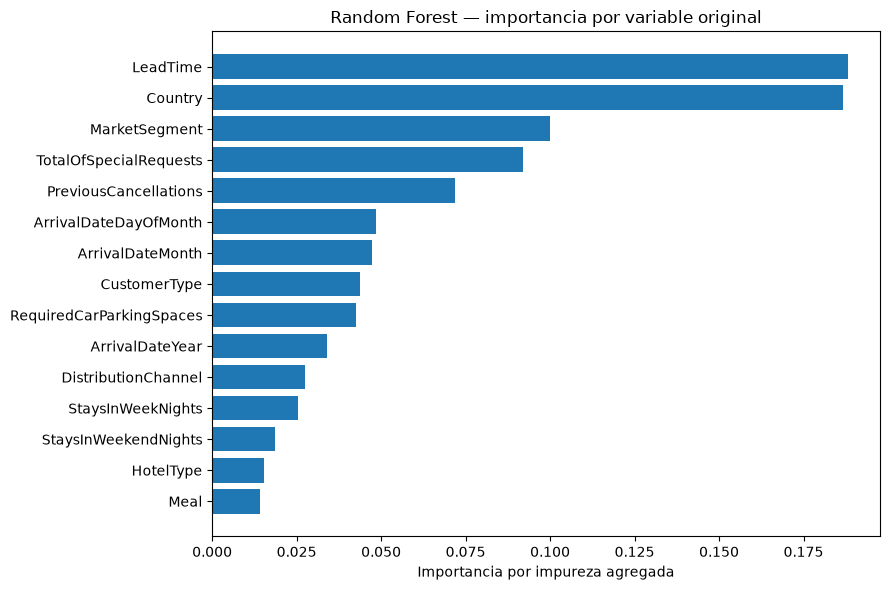

In [12]:
rf_preprocessor = best_random_forest.named_steps["preprocessor"]
rf_classifier = best_random_forest.named_steps["model"]
rf_transformed_names = rf_preprocessor.get_feature_names_out()
rf_numeric_features, rf_categorical_features = get_feature_types(
    X_selected_train, require_all_categorical=False
)
rf_source_features = [*rf_numeric_features]
rf_onehot = rf_preprocessor.named_transformers_["categorical"].named_steps["onehot"]
for feature, categories in zip(rf_categorical_features, rf_onehot.categories_):
    rf_source_features.extend([feature] * len(categories))
if len(rf_source_features) != len(rf_transformed_names):
    raise ValueError("No se pudo reconstruir el origen de las columnas transformadas.")

rf_transformed_importance = pd.DataFrame({
    "transformed_feature": rf_transformed_names,
    "source_feature": rf_source_features,
    "impurity_importance": rf_classifier.feature_importances_,
})
rf_importance = (
    rf_transformed_importance
    .groupby("source_feature", as_index=False)["impurity_importance"].sum()
    .sort_values("impurity_importance", ascending=False)
)
display(rf_importance.round(6))

plot_importance = rf_importance.head(15).sort_values("impurity_importance")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_importance["source_feature"], plot_importance["impurity_importance"])
ax.set_xlabel("Importancia por impureza agregada")
ax.set_title("Random Forest — importancia por variable original")
plt.tight_layout()
plt.show()

## Conclusiones

La base depurada de 24 features alcanzó ROC AUC CV 0,926422 con el bosque fijo, frente a 0,925012 del conjunto podado, y ganó cuatro de los cinco folds. La reducción elegida para un árbol individual no se trasladó al ensemble: algunas variables débiles pueden aportar diversidad entre árboles.

La búsqueda completa seleccionó profundidad libre, `max_features=0.5` y `min_samples_leaf=5`. La grilla económica con 100 árboles confirmó los mismos parámetros y obtuvo ROC AUC CV 0,941260, apenas 0,000307 menos que la ejecución con 300 árboles.

El modelo presenta sobreajuste: ROC AUC de entrenamiento 0,987653, CV 0,941260 y holdout 0,842641. El gap train–CV es 0,046393 y el gap CV–2017, 0,098618. Con threshold 0,5 alcanza Accuracy 0,769312, Precision 0,748885, Recall 0,607621 y F1 0,670898.

Random Forest es el modelo más preciso hasta esta etapa, pero omite casi cuatro de cada diez cancelaciones y queda por debajo de Logistic Regression engineered en ROC AUC temporal y F1. Se considera cerrado y no se reajusta a partir de 2017.